# Code Assignment 16 — K-Means Clustering (Mall Customers, 2–3 Features Only)

**Format:** Instructor Guidance → Your Task (step-by-step) → We Share (reflection)

**Goal:** Build a **K-Means** clustering model using **only 2–3 simple numeric features** with **minimal cleaning**, pick **K** via **Elbow + Silhouette** on the **train split**, and sanity-check **generalization** on the **test split**. Then profile clusters in plain business terms.

**Dataset (simple, non-transportation):** *Mall Customers* (public, widely used teaching dataset)  

> We will only use **2–3 numeric columns**: e.g., `Age`, `Annual Income (k$)`, `Spending Score (1-100)`.  



## Instructor Guidance (Pseudocode + Docs)

**Docs:**  
- `train_test_split`: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html  
- `StandardScaler`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html  
- `KMeans`: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html  
- `silhouette_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

### Pseudocode Plan (Minimal)
1) **Load CSV** → preview columns/shape.  
2) **Pick 2–3 numeric features** (e.g., Age, Income, SpendingScore).  
3) **Drop NA only** on those columns.  
4) **Split**: `train_test_split(X, test_size=0.2, random_state=42)`.  
5) **Scale**: `StandardScaler` — **fit on TRAIN**, transform TRAIN and TEST.  
6) **Choose K** on TRAIN: loop K=2..8 → plot **Elbow (inertia)** and **Silhouette**.  
7) **Fit final KMeans** on TRAIN with your chosen K; predict TRAIN & TEST labels.  
8) **Sanity check**: report **Silhouette (TRAIN vs TEST)**.  
9) **Profile clusters**: per-cluster means of your 2–3 features (no extra cleaning).  
10) **Reflection**: justify K, describe segments, suggest one action per segment.


## Your Task — Step-by-Step
Work in pairs. Keep code minimal. Use only 2–3 features.

### 1) Imports & Settings

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

### 2) Load the Mall Customers CSV & Preview

In [2]:
df = pd.read_csv("/Users/Marcy_Student/Downloads/Mall_Customers copy.csv")
display(df.shape)
display(df.head())

(200, 5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 3) Select **2–3 Numeric Features** (no heavy cleaning)
Choose from:
- `Age`
- `Annual Income (k$)`
- `Spending Score (1-100)`

> Keep it simple: e.g., use **Age + Spending Score** (2D) or **Age + Income + Spending Score** (3D).


In [3]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

### 4) Train–Test Split (for model generalization sanity check)

In [4]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

### 5) Scale (fit on TRAIN only), then Explore K on TRAIN (Elbow + Silhouette)

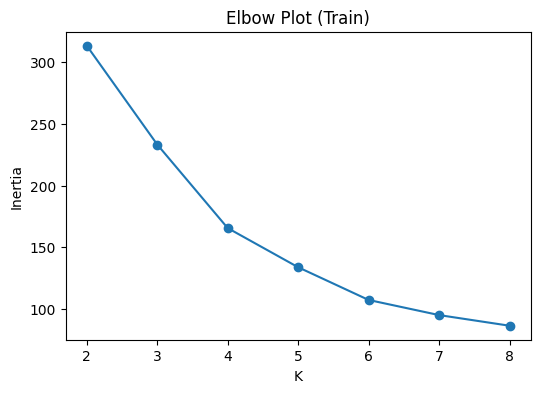

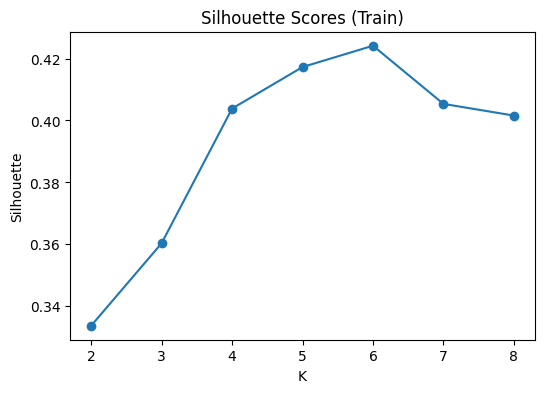

[313.4364325909566, 233.3173124094294, 165.5764764162693, 133.82645325666388, 107.29827981804465, 95.0401690557199, 86.41261743426247]
[0.33369448027171933, 0.3603372722938299, 0.4038506787620692, 0.4172682022952781, 0.42415216143147366, 0.4053610161683654, 0.40158530447292246]


In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

inertias = []
sil_scores = []

K_values = range(2, 9)

# For loop to go through K's
for K in K_values:
    kmeans = KMeans(n_clusters=K, random_state=42, n_init=10, max_iter=300)
    kmeans.fit(X_train_scaled)
    
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_train_scaled, kmeans.labels_))

plt.figure(figsize=(6,4))
plt.plot(K_values, inertias, marker='o')
plt.title("Elbow Plot (Train)")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(K_values, sil_scores, marker='o')
plt.title("Silhouette Scores (Train)")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.show()

print(inertias)
print(sil_scores)

### 6) Choose **K** (justify), Fit Final Model on TRAIN, Check Stability on TEST
- Report **Silhouette TRAIN vs TEST** (higher is better; similar values suggest stability).

In [6]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_final.fit(X_train_scaled)

train_labels = kmeans_final.labels_
test_labels  = kmeans_final.predict(X_test_scaled)

sil_train = silhouette_score(X_train_scaled, train_labels)
sil_test  = silhouette_score(X_test_scaled, test_labels)

print("Silhouette (TRAIN):", sil_train)
print("Silhouette (TEST): ", sil_test)

Silhouette (TRAIN): 0.4172682022952781
Silhouette (TEST):  0.36818210171632415


### 7) Profile Clusters (Business-Readable)
- Use the **original (unscaled)** features for interpretation.
- Show per-cluster means of your **2–3 features**.

In [7]:
X_train['Cluster'] = train_labels
cluster_means = X_train.groupby('Cluster').mean()
cluster_means

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,25.627907,39.767442,63.139535
1,45.764706,27.117647,17.588235
2,33.142857,87.285714,82.257143
3,38.925926,87.925926,19.629630
4,56.184211,55.184211,48.973684


## We Share — Reflection (2 short paragraphs)

1) **K choice & stability:** What **K** did you choose and why (Elbow bend, Silhouette peak/plateau, simplicity)? Report **Silhouette (TRAIN vs TEST)** — did structure persist, or did it collapse on test?  

The chosen K = 5 for the K-Means model. The Elbow plot showed a bend around K=5, indicating diminishing returns in inertia with additional clusters after that point, and the Silhouette score peaked at K=5 (0.424), suggesting well-separated, cohesive clusters. On the train set, the Silhouette was 0.417, and on the test set, it was 0.368. The small drop on test shows that the cluster structure is consistent and the model generalizes reasonably well without collapsing.

2) **Segments & actions:** Give short names to your segments (e.g., “Young High-Spend,” “Mid-Age Value-Seeker,” “Older Low-Spend”) and suggest **one actionable idea** for each (targeted offers, product mix, messaging).

Young Adult Moderate-Spend – Target trendy seasonal promotions. 

Middle-Age Low-Spend – Offer value bundles. 

Young Adult High-Spend – Focus on premium products and loyalty programs.

Adult Low-Spend – Try exclusive offers.

Middle-Age Moderate-Spend – family oriented products.

> Bonus: Re-run with **just 2 features** (e.g., **Income + SpendingScore**) and compare stability & interpretability.
